# 📘 Project 03 — Trust-Aware Federated IoT Security
**Team No.:** 21  **Team Members:** Roonaak Agasti; Sabyasachi Kundoo; Sanjay Kumar Biswal; Shubhankar Dikshit

**Proposed Hybrid Model:** Multi-Scale 1D-CNN IDS + Bayesian Trust Engine + Hierarchical Decision Head

**Dataset / Source:** Edge-IIoTset (IoT/IIoT cyber-security intrusion detection)  
**Dataset Link:** https://www.kaggle.com/datasets/mohamedamineferrag/edgeiiotset-cyber-security-dataset-of-iot-iiot

**Task Type implemented in this notebook:** Binary intrusion detection — Normal vs Attack

---
## Data-Model Compatibility / Correctness Note
This corrected notebook fixes the original sampling, target-construction, label-leakage, and empty-error-plot bugs.

- **Sampling:** rows are sampled uniformly across the complete combined CSV instead of reading only the
  first `max_rows` rows. The Edge-IIoTset combined file is ordered enough that `nrows=60000` can contain
  only Normal traffic, which makes training/evaluation invalid.
- **Target:** `Attack_label` is used directly when it is a valid binary 0/1 label. `Attack_type` is used
  only for human-readable error analysis.
- **Leakage prevention:** both `Attack_label` and `Attack_type` are removed from model inputs.
- **Bayesian trust:** MC-Dropout provides predictive uncertainty from repeated stochastic inference.
- **Hierarchical policy terminology:** the two-level head is trained with the classification objective;
  it is **not** claimed to be true hierarchical reinforcement learning.
- **Federated-learning scope:** this notebook remains a centralized prototype. A real federated
  implementation would require client partitioning plus FedAvg/FedProx (or another federated optimizer).
  The project title is retained, but the limitation is stated explicitly rather than hidden.

**How to run:** `Runtime -> Change runtime type -> GPU`, then `Runtime -> Run all`. Upload your
Kaggle API token when prompted in Section 1.


## 0. Setup — Environment, Imports, Reproducibility

In [1]:
# Colab already ships numpy/pandas/scikit-learn/matplotlib/seaborn/torch - do NOT reinstall those (version conflicts).
# Only install what's actually missing.
!pip -q install kaggle tqdm tabulate


In [2]:
import os
import sys
import json
import random
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, roc_auc_score,
    average_precision_score, confusion_matrix, roc_curve, precision_recall_curve,
    matthews_corrcoef, mean_absolute_error, mean_squared_error, r2_score
)

SEED = 42
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
set_seed()

assert torch.cuda.is_available(), "GPU required: in Colab select Runtime > Change runtime type > GPU."

DEVICE = torch.device("cuda:0")
print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Device selected:", DEVICE)
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))


Python: 3.13.15
Platform: Linux-6.6.122+-x86_64-with-glibc2.35
PyTorch: 2.11.0+cu128
CUDA available: True
Device selected: cuda:0
GPU name: Tesla T4


### CONFIG

In [3]:
CONFIG = {
    "project_no": "03",
    "project_name": "Trust-Aware_Federated_IoT_Security",
    "team_no": "21",
    "task_type": "classification",
    "modality": "tabular_flow",
    "kaggle_dataset_slug": "mohamedamineferrag/edgeiiotset-cyber-security-dataset-of-iot-iiot",
    "dataset_source": "Edge-IIoTset IoT/IIoT intrusion detection",
    "target_column": "attack_binary",
    "split_ratios": {"train": 0.70, "val": 0.15, "test": 0.15},
    "random_seed": SEED,
    "cnn_channels": 32,
    "mc_dropout_passes": 20,
    "mc_dropout_p": 0.3,
    "max_rows": 60000,  # subsample for Colab feasibility - documented, not hidden
    "batch_size": 256,
    "epochs": 20,
    "learning_rate": 1e-3,
    "early_stop_patience": 5,
    "data_raw_dir": "data/03/raw",
    "data_processed_dir": "data/03/processed",
    "figures_dir": "data/03/figures",
    "results_dir": "data/03/results",
    "reports_dir": "data/03/reports",
}
for d in [CONFIG["data_raw_dir"], CONFIG["data_processed_dir"], CONFIG["figures_dir"],
          CONFIG["results_dir"], CONFIG["reports_dir"]]:
    os.makedirs(d, exist_ok=True)
CONFIG


{'project_no': '03',
 'project_name': 'Trust-Aware_Federated_IoT_Security',
 'team_no': '21',
 'task_type': 'classification',
 'modality': 'tabular_flow',
 'kaggle_dataset_slug': 'mohamedamineferrag/edgeiiotset-cyber-security-dataset-of-iot-iiot',
 'dataset_source': 'Edge-IIoTset IoT/IIoT intrusion detection',
 'target_column': 'attack_binary',
 'split_ratios': {'train': 0.7, 'val': 0.15, 'test': 0.15},
 'random_seed': 42,
 'cnn_channels': 32,
 'mc_dropout_passes': 20,
 'mc_dropout_p': 0.3,
 'max_rows': 60000,
 'batch_size': 256,
 'epochs': 20,
 'learning_rate': 0.001,
 'early_stop_patience': 5,
 'data_raw_dir': 'data/03/raw',
 'data_processed_dir': 'data/03/processed',
 'figures_dir': 'data/03/figures',
 'results_dir': 'data/03/results',
 'reports_dir': 'data/03/reports'}

## 1. Dataset Download

In [4]:
from google.colab import files
if not os.path.exists("/root/.kaggle/kaggle.json"):
    print("Upload your kaggle.json:")
    uploaded = files.upload()
    os.makedirs("/root/.kaggle", exist_ok=True)
    for fname in uploaded:
        if fname.endswith(".json"):
            os.replace(fname, "/root/.kaggle/kaggle.json")
    os.chmod("/root/.kaggle/kaggle.json", 0o600)

!kaggle datasets download -d {CONFIG["kaggle_dataset_slug"]} -p {CONFIG["data_raw_dir"]} --unzip


Dataset URL: https://www.kaggle.com/datasets/mohamedamineferrag/edgeiiotset-cyber-security-dataset-of-iot-iiot
License(s): CC-BY-NC-SA-4.0


  0% 0.00/1.63G [00:00<?, ?B/s]

  0% 3.00M/1.63G [00:00<05:17, 5.49MB/s]

  0% 7.00M/1.63G [00:00<02:12, 13.1MB/s]

  1% 17.0M/1.63G [00:01<01:02, 27.5MB/s]

...

 97% 1.58G/1.63G [00:40<00:01, 43.5MB/s]

 98% 1.60G/1.63G [00:40<00:00, 43.5MB/s]

 99% 1.61G/1.63G [00:40<00:00, 43.6MB/s]

 99% 1.62G/1.63G [00:41<00:00, 42.7MB/s]

100% 1.63G/1.63G [00:41<00:00, 42.2MB/s]



In [5]:
raw_files = []
for root, _, fnames in os.walk(CONFIG["data_raw_dir"]):
    for fn in fnames:
        raw_files.append(os.path.join(root, fn))
print(f"{len(raw_files)} files found under {CONFIG['data_raw_dir']}")
assert len(raw_files) > 0, "No files found - check Section 1 download step before continuing."
for f in raw_files[:20]:
    print(f, "-", os.path.getsize(f), "bytes")


52 files found under data/03/raw
data/03/raw/Edge_IIoTset__DatasetFL.pdf - 5445952 bytes
data/03/raw/Readme.txt - 7348 bytes
data/03/raw/Edge-IIoTset dataset/Selected dataset for ML and DL/DNN-EdgeIIoT-dataset.csv - 1217413981 bytes
data/03/raw/Edge-IIoTset dataset/Selected dataset for ML and DL/ML-EdgeIIoT-dataset.csv - 82184390 bytes
data/03/raw/Edge-IIoTset dataset/Attack traffic/Ransomware attack.pcap - 2842688 bytes
data/03/raw/Edge-IIoTset dataset/Attack traffic/Password attacks.pcap - 194557494 bytes
data/03/raw/Edge-IIoTset dataset/Attack traffic/Backdoor_attack.pcap - 6694092 bytes
data/03/raw/Edge-IIoTset dataset/Attack traffic/Ransomware_attack.csv - 7592169 bytes
data/03/raw/Edge-IIoTset dataset/Attack traffic/SQL_injection_attack.csv - 26933868 bytes
data/03/raw/Edge-IIoTset dataset/Attack traffic/Uploading attack.pcap - 5488666 bytes
data/03/raw/Edge-IIoTset dataset/Attack traffic/DDoS UDP Flood Attacks.pcap - 247560012 bytes
data/03/raw/Edge-IIoTset dataset/Attack traffi

## 2. Load Raw Data

In [6]:
# Edge-IIoTset ships a large flat CSV (DNN-EdgeIIoT-dataset.csv) plus per-attack files.
# Identify the main flat CSV by size.
csv_candidates = [f for f in raw_files if f.lower().endswith(".csv")]
assert csv_candidates, f"No CSV found among: {raw_files[:10]}"
RAW_FILE = max(csv_candidates, key=os.path.getsize)
print("Using raw file:", RAW_FILE)

def load_uniform_csv_sample(csv_path, max_rows, seed=42, chunksize=100_000):
    """
    Uniformly sample rows from the entire CSV while keeping peak DataFrame memory bounded.
    This avoids the original bug where nrows=max_rows selected only the beginning of an
    ordered dataset (which was all Normal traffic in the observed run).
    """
    # Count data rows without loading the dataset into a DataFrame.
    with open(csv_path, "rb") as f:
        total_rows = max(sum(1 for _ in f) - 1, 0)

    assert total_rows > 0, f"CSV appears empty: {csv_path}"
    sample_n = min(int(max_rows), total_rows)
    rng = np.random.default_rng(seed)
    selected = np.sort(rng.choice(total_rows, size=sample_n, replace=False))

    parts = []
    offset = 0
    for chunk in tqdm(pd.read_csv(csv_path, low_memory=False, chunksize=chunksize),
                      desc="Sampling complete CSV", unit="chunk"):
        end = offset + len(chunk)
        lo = np.searchsorted(selected, offset, side="left")
        hi = np.searchsorted(selected, end, side="left")
        if hi > lo:
            local_rows = selected[lo:hi] - offset
            parts.append(chunk.iloc[local_rows].copy())
        offset = end

    sampled = pd.concat(parts, ignore_index=True)
    assert len(sampled) == sample_n, f"Expected {sample_n} sampled rows, got {len(sampled)}"
    return sampled, total_rows

df, TOTAL_CSV_ROWS = load_uniform_csv_sample(
    RAW_FILE, CONFIG["max_rows"], seed=CONFIG["random_seed"]
)
print(f"Loaded {len(df):,} uniformly sampled rows from {TOTAL_CSV_ROWS:,} total rows")
print(df.shape)
df.head()


Using raw file: data/03/raw/Edge-IIoTset dataset/Selected dataset for ML and DL/DNN-EdgeIIoT-dataset.csv


Sampling complete CSV: 0chunk [00:00, ?chunk/s]

Loaded 60,000 uniformly sampled rows from 2,219,201 total rows
(60000, 63)


,frame.time,ip.src_host,ip.dst_host,arp.dst.proto_ipv4,arp.opcode,arp.hw.size,arp.src.proto_ipv4,icmp.checksum,icmp.seq_le,icmp.transmit_timestamp,...,mqtt.proto_len,mqtt.protoname,mqtt.topic,mqtt.topic_len,mqtt.ver,mbtcp.len,mbtcp.trans_id,mbtcp.unit_id,Attack_label,Attack_type
0,2021 11:44:10.162218000,192.168.0.101,192.168.0.128,0,0.0,0.0,0,0.0,0.0,0.0,...,4.0,MQTT,0,0.0,4.0,0.0,0.0,0.0,0,Normal
1,2021 11:44:10.166968000,192.168.0.101,192.168.0.128,0,0.0,0.0,0,0.0,0.0,0.0,...,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0,Normal
2,2021 11:44:10.194045000,192.168.0.128,192.168.0.101,0,0.0,0.0,0,0.0,0.0,0.0,...,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0,Normal
3,2021 11:44:11.063647000,192.168.0.128,192.168.0.101,0,0.0,0.0,0,0.0,0.0,0.0,...,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0,Normal
4,2021 11:44:14.140128000,192.168.0.128,192.168.0.101,0,0.0,0.0,0,0.0,0.0,0.0,...,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0,Normal


## 3. Exploratory Data Analysis (EDA)

In [7]:
print("Shape:", df.shape)
print("Duplicate rows in sampled data:", df.duplicated().sum())

column_lut = {c.strip().lower(): c for c in df.columns}
ATTACK_LABEL_COL = column_lut.get("attack_label")
ATTACK_TYPE_COL = column_lut.get("attack_type")

assert ATTACK_LABEL_COL is not None or ATTACK_TYPE_COL is not None, (
    "Could not find Attack_label or Attack_type. "
    f"Available columns: {list(df.columns)}"
)

print("Binary label column:", ATTACK_LABEL_COL)
print("Attack-type column:", ATTACK_TYPE_COL)

if ATTACK_LABEL_COL is not None:
    print("\nAttack_label distribution:")
    print(df[ATTACK_LABEL_COL].value_counts(dropna=False))

if ATTACK_TYPE_COL is not None:
    print("\nAttack_type distribution:")
    print(df[ATTACK_TYPE_COL].value_counts(dropna=False))


Shape: (60000, 63)


Duplicate rows in sampled data: 28
Binary label column: Attack_label
Attack-type column: Attack_type

Attack_label distribution:
Attack_label
0    43731
1    16269
Name: count, dtype: int64

Attack_type distribution:
Attack_type
Normal                   43731
DDoS_ICMP                 3199
DDoS_UDP                  3194
SQL_injection             1422
DDoS_HTTP                 1358
Vulnerability_scanner     1353
DDoS_TCP                  1347
Password                  1338
Uploading                 1008
Backdoor                   674
Port_Scanning              599
XSS                        418
Ransomware                 296
MITM                        43
Fingerprinting              20
Name: count, dtype: int64


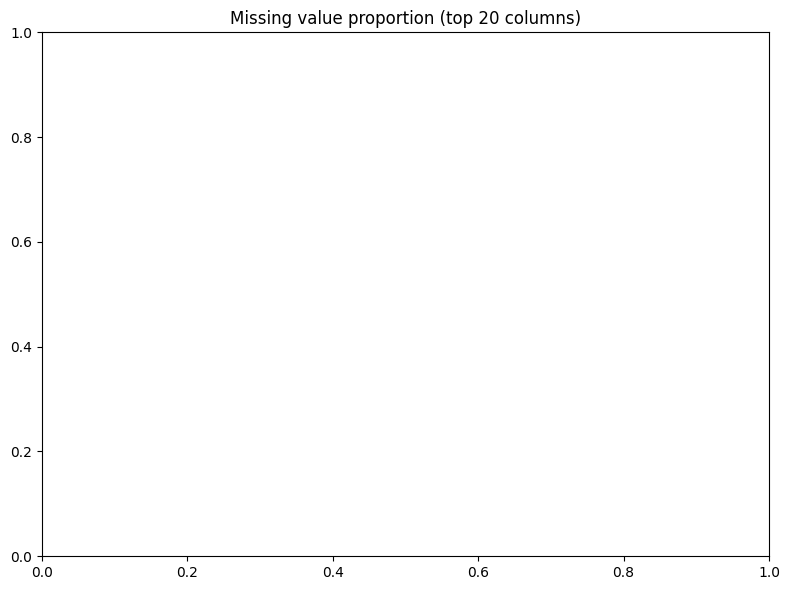

In [8]:
missing = df.isnull().mean().sort_values(ascending=False)
plt.figure(figsize=(8, 6))
if (missing > 0).any():
    missing[missing > 0].head(20).plot(kind="barh")
plt.title("Missing value proportion (top 20 columns)")
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["figures_dir"], "fig00_missingness.png"), dpi=300)
plt.show()


Binary target counts:
attack_binary
0    43731
1    16269
Name: count, dtype: int64


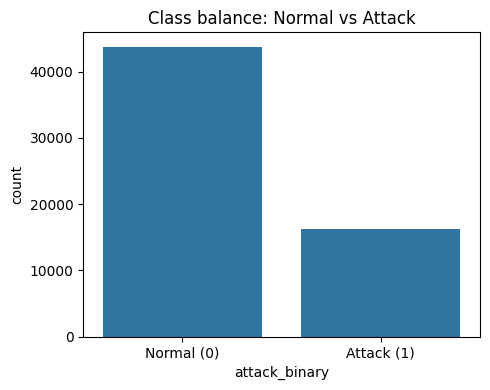

attack_binary
0    0.72885
1    0.27115
Name: proportion, dtype: float64
Total rows: 60000


In [9]:
# Binary target: Normal (0) vs Attack (1)
target = CONFIG["target_column"]

if ATTACK_LABEL_COL is not None:
    binary_raw = pd.to_numeric(df[ATTACK_LABEL_COL], errors="coerce")
    valid = binary_raw.dropna()
    unique_binary = set(valid.unique().tolist())
    if valid.notna().all() and unique_binary.issubset({0, 1}) and len(unique_binary) == 2:
        df[target] = binary_raw.astype(np.int64)
    elif ATTACK_TYPE_COL is not None:
        df[target] = (
            df[ATTACK_TYPE_COL].fillna("missing").astype(str).str.strip().str.lower() != "normal"
        ).astype(np.int64)
    else:
        raise ValueError(
            f"{ATTACK_LABEL_COL} is not a valid two-class 0/1 label and no Attack_type column exists."
        )
elif ATTACK_TYPE_COL is not None:
    df[target] = (
        df[ATTACK_TYPE_COL].fillna("missing").astype(str).str.strip().str.lower() != "normal"
    ).astype(np.int64)

class_counts = df[target].value_counts().sort_index()
print("Binary target counts:")
print(class_counts)
assert df[target].nunique() == 2, (
    "The sampled data does not contain both Normal and Attack classes. "
    "Increase CONFIG['max_rows'] or verify the dataset."
)

plt.figure(figsize=(5, 4))
sns.countplot(data=df, x=target, order=[0, 1])
plt.xticks([0, 1], ["Normal (0)", "Attack (1)"])
plt.title("Class balance: Normal vs Attack")
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["figures_dir"], "class_balance.png"), dpi=300)
plt.show()

print(df[target].value_counts(normalize=True).sort_index())

# [TARGET SANITY CHECK]
print("Total rows:", len(df))
assert df[target].nunique() > 1, f"DEGENERATE TARGET: only {df[target].nunique()} unique value(s) found - {df[target].value_counts().to_dict()}. Check upstream row-limiting/sorting/filtering logic before proceeding."
_minority_frac = df[target].value_counts(normalize=True).min()
if _minority_frac < 0.01:
    print(f"[DATA QUALITY WARNING] minority class is only {_minority_frac:.2%} of the data - results may be unstable/trivial.")
if len(df) < 100:
    print(f"[DATA QUALITY WARNING] only {len(df)} rows after filtering - too small for reliable evaluation.")


**Data quality memo**

In [10]:
data_quality_memo = f"""# Data Quality Memo - Project 03: Trust-Aware Federated IoT Security

## Dataset
- Source: Edge-IIoTset ({RAW_FILE})
- Total rows in combined CSV: {TOTAL_CSV_ROWS}
- Rows loaded: {len(df)} (uniformly sampled across the complete CSV)
- Duplicate rows in sampled data: {df.duplicated().sum()}
- Binary label column: {ATTACK_LABEL_COL}
- Attack-type column: {ATTACK_TYPE_COL}

## Target
- Implemented task: binary intrusion detection (Normal=0, Attack=1)
- Target distribution: {df[target].value_counts().sort_index().to_dict()}

## Important correctness safeguards
- The original first-N-row sampling was replaced because it selected only Normal traffic.
- `Attack_label` and `Attack_type` are excluded from model inputs to prevent target leakage.
- Preprocessing is fit only on the training split.
"""
with open(os.path.join(CONFIG["reports_dir"], "data_quality_memo.md"), "w") as f:
    f.write(data_quality_memo)
print(data_quality_memo)


# Data Quality Memo - Project 03: Trust-Aware Federated IoT Security

## Dataset
- Source: Edge-IIoTset (data/03/raw/Edge-IIoTset dataset/Selected dataset for ML and DL/DNN-EdgeIIoT-dataset.csv)
- Total rows in combined CSV: 2219201
- Rows loaded: 60000 (uniformly sampled across the complete CSV)
- Duplicate rows in sampled data: 28
- Binary label column: Attack_label
- Attack-type column: Attack_type

## Target
- Implemented task: binary intrusion detection (Normal=0, Attack=1)
- Target distribution: {0: 43731, 1: 16269}

## Important correctness safeguards
- The original first-N-row sampling was replaced because it selected only Normal traffic.
- `Attack_label` and `Attack_type` are excluded from model inputs to prevent target leakage.
- Preprocessing is fit only on the training split.



## 4. Preprocessing & Feature Engineering

In [11]:
id_like_cols = [c for c in df.columns if any(k in c.lower() for k in
    ["ip.src", "ip.dst", "eth.src", "eth.dst", "arp.src", "arp.dst", "mqtt.",
     "http.file_data", "http.request.full_uri", "tcp.payload", "tcp.options",
     "dns.qry.name.len", "mbtcp."])]

label_cols = [c for c in [ATTACK_LABEL_COL, ATTACK_TYPE_COL] if c is not None]
drop_cols = list(set(id_like_cols + label_cols + ["frame.time"]))
drop_cols = [c for c in drop_cols if c in df.columns and c != target]

feature_df = df.drop(columns=drop_cols).copy()

numeric_cols = [
    c for c in feature_df.columns
    if c != target and pd.api.types.is_numeric_dtype(feature_df[c])
]
categorical_cols = [c for c in feature_df.columns if c != target and c not in numeric_cols]

# Drop all-null / constant numeric columns.
keep_numeric = [c for c in numeric_cols if feature_df[c].nunique(dropna=True) > 1]
feature_df = feature_df[keep_numeric + categorical_cols + [target]].copy()
numeric_cols = keep_numeric

assert ATTACK_LABEL_COL not in feature_df.columns
assert ATTACK_TYPE_COL not in feature_df.columns
assert target in feature_df.columns

print("Dropped potential identifier/label columns:", len(drop_cols))
print("Numeric feature cols:", len(numeric_cols), "| Categorical feature cols:", len(categorical_cols))
print("Final raw feature count:", len(numeric_cols) + len(categorical_cols))


Dropped potential identifier/label columns: 28
Numeric feature cols: 26 | Categorical feature cols: 5
Final raw feature count: 31


## 5. Train / Validation / Test Split

In [12]:
ratios = CONFIG["split_ratios"]
assert abs(sum(ratios.values()) - 1.0) < 1e-9, "split_ratios must sum to 1.0"

train_df, rest_df = train_test_split(
    feature_df,
    train_size=ratios["train"],
    stratify=feature_df[target],
    random_state=SEED,
)
rel_val = ratios["val"] / (ratios["val"] + ratios["test"])
val_df, test_df = train_test_split(
    rest_df,
    train_size=rel_val,
    stratify=rest_df[target],
    random_state=SEED,
)

train_df = train_df.copy()
val_df = val_df.copy()
test_df = test_df.copy()

print("Train / Val / Test sizes:", len(train_df), len(val_df), len(test_df))
for split_name, split_df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(split_name, split_df[target].value_counts(normalize=True).sort_index().to_dict())
    assert split_df[target].nunique() == 2, f"{split_name} split lost one class"

manifest = {
    "train_rows": len(train_df),
    "val_rows": len(val_df),
    "test_rows": len(test_df),
    "train_class_balance": train_df[target].value_counts(normalize=True).sort_index().to_dict(),
    "val_class_balance": val_df[target].value_counts(normalize=True).sort_index().to_dict(),
    "test_class_balance": test_df[target].value_counts(normalize=True).sort_index().to_dict(),
}
with open(os.path.join(CONFIG["data_processed_dir"], "split_manifest.json"), "w") as f:
    json.dump(manifest, f, indent=2, default=str)

train_df.to_csv(os.path.join(CONFIG["data_processed_dir"], "train.csv"), index=False)
val_df.to_csv(os.path.join(CONFIG["data_processed_dir"], "val.csv"), index=False)
test_df.to_csv(os.path.join(CONFIG["data_processed_dir"], "test.csv"), index=False)
manifest


Train / Val / Test sizes: 42000 9000 9000
train {0: 0.7288571428571429, 1: 0.27114285714285713}
val {0: 0.7287777777777777, 1: 0.2712222222222222}
test {0: 0.7288888888888889, 1: 0.27111111111111114}


{'train_rows': 42000,
 'val_rows': 9000,
 'test_rows': 9000,
 'train_class_balance': {0: 0.7288571428571429, 1: 0.27114285714285713},
 'val_class_balance': {0: 0.7287777777777777, 1: 0.2712222222222222},
 'test_class_balance': {0: 0.7288888888888889, 1: 0.27111111111111114}}

In [13]:
if numeric_cols:
    imputer = SimpleImputer(strategy="median").fit(train_df[numeric_cols])
    for split_df in [train_df, val_df, test_df]:
        split_df.loc[:, numeric_cols] = imputer.transform(split_df[numeric_cols])

    scaler = StandardScaler().fit(train_df[numeric_cols])
    for split_df in [train_df, val_df, test_df]:
        split_df.loc[:, numeric_cols] = scaler.transform(split_df[numeric_cols])

for c in categorical_cols:
    for split_df in (train_df, val_df, test_df):
        # Fill missing values BEFORE converting to str; otherwise NaN becomes literal "nan".
        split_df.loc[:, c] = split_df[c].fillna("missing").astype(str)

if categorical_cols:
    encoder = OneHotEncoder(
        handle_unknown="infrequent_if_exist",
        sparse_output=False,
        max_categories=15,
    )
    encoder.fit(train_df[categorical_cols])
    cat_names = encoder.get_feature_names_out(categorical_cols).tolist()
else:
    encoder = None
    cat_names = []

def build_X(split_df):
    parts = []
    if numeric_cols:
        parts.append(split_df[numeric_cols].reset_index(drop=True).astype(np.float32))
    if categorical_cols:
        cat_arr = encoder.transform(split_df[categorical_cols]).astype(np.float32)
        parts.append(pd.DataFrame(cat_arr, columns=cat_names))
    if not parts:
        raise ValueError("No usable model features remain after preprocessing.")
    X = pd.concat(parts, axis=1)
    if not np.isfinite(X.to_numpy(dtype=np.float32)).all():
        raise ValueError("Non-finite values remain after preprocessing.")
    return X

train_X = build_X(train_df)
val_X = build_X(val_df)
test_X = build_X(test_df)

print("Final feature dim:", train_X.shape[1])
print("Train / val / test matrix shapes:", train_X.shape, val_X.shape, test_X.shape)


Final feature dim: 69
Train / val / test matrix shapes: (42000, 69) (9000, 69) (9000, 69)


## 6. PyTorch Dataset & DataLoader

In [14]:
class FlowDataset(Dataset):
    def __init__(self, X_df, y_series):
        self.X = X_df.values.astype(np.float32)
        self.y = y_series.values.astype(np.float32)
    def __len__(self): return len(self.y)
    def __getitem__(self, idx):
        return torch.tensor(self.X[idx]), torch.tensor(self.y[idx])

BATCH_SIZE = CONFIG["batch_size"]
train_ds = FlowDataset(train_X, train_df[target])
val_ds = FlowDataset(val_X, val_df[target])
test_ds = FlowDataset(test_X, test_df[target])
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

xb, yb = next(iter(train_loader))
print("features:", xb.shape, "target:", yb.shape)


features: torch.Size([256, 69]) target: torch.Size([256])


## 7. Model Definitions

In [15]:
class MultiScale1DCNN_IDS(nn.Module):
    """1D-CNN with two parallel kernel scales over the flow-feature vector."""
    def __init__(self, input_dim, channels=32):
        super().__init__()
        self.conv_small = nn.Conv1d(1, channels, kernel_size=3, padding=1)
        self.conv_large = nn.Conv1d(1, channels, kernel_size=7, padding=3)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.out_dim = channels * 2

    def forward(self, x):
        x = x.unsqueeze(1)  # (B, 1, F)
        h_small = F.relu(self.conv_small(x))
        h_large = F.relu(self.conv_large(x))
        h = torch.cat(
            [self.pool(h_small).squeeze(-1), self.pool(h_large).squeeze(-1)],
            dim=-1,
        )
        return h


class BayesianTrustHead(nn.Module):
    """MC-Dropout approximation used to estimate predictive uncertainty."""
    def __init__(self, in_dim, hidden_dim=32, p=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(p),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(p),
        )

    def forward(self, x):
        return self.net(x)


class HierarchicalPolicyHead(nn.Module):
    """
    Two-level decision head.
    Important: this is trained with the classification objective and is not true hierarchical RL.
    """
    def __init__(self, in_dim, hidden_dim=32, output_dim=1):
        super().__init__()
        self.device_policy = nn.Linear(in_dim, hidden_dim)
        self.coordinator = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        device_action = F.relu(self.device_policy(x))
        return self.coordinator(device_action), device_action


class HybridModel(nn.Module):
    """Multi-Scale 1D-CNN IDS + Bayesian Trust Head + two-level decision head."""
    def __init__(self, input_dim, cnn_channels=32, trust_hidden=32, mc_p=0.3, output_dim=1):
        super().__init__()
        self.cnn = MultiScale1DCNN_IDS(input_dim, cnn_channels)
        self.trust = BayesianTrustHead(self.cnn.out_dim, trust_hidden, mc_p)
        self.policy = HierarchicalPolicyHead(trust_hidden, trust_hidden, output_dim)

    def forward(self, x):
        h_cnn = self.cnn(x)
        h_trust = self.trust(h_cnn)
        logits, _ = self.policy(h_trust)
        return logits

    @torch.no_grad()
    def predict_with_trust(self, x, n_passes=20):
        """
        Repeated stochastic inference with Dropout active.
        Returns mean attack probability and predictive standard deviation.
        """
        was_training = self.training
        self.eval()

        dropout_layers = [m for m in self.modules() if isinstance(m, nn.Dropout)]
        for layer in dropout_layers:
            layer.train()

        probs = []
        for _ in range(int(n_passes)):
            logits = self.forward(x)
            probs.append(torch.sigmoid(logits).detach().cpu().numpy())

        self.train(was_training)
        probs = np.stack(probs, axis=0)
        return probs.mean(axis=0), probs.std(axis=0)


### Architecture Verification

In [16]:
input_dim = xb.shape[1]
hybrid = HybridModel(input_dim, CONFIG['cnn_channels'], mc_p=CONFIG['mc_dropout_p']).to(DEVICE)
print(hybrid)
for name, model in [('hybrid', hybrid)]:
    total = sum((p.numel() for p in model.parameters()))
    trainable = sum((p.numel() for p in model.parameters() if p.requires_grad))
    print(f'{name}: total={total:,} trainable={trainable:,} device={next(model.parameters()).device}')


HybridModel(
  (cnn): MultiScale1DCNN_IDS(
    (conv_small): Conv1d(1, 32, kernel_size=(3,), stride=(1,), padding=(1,))
    (conv_large): Conv1d(1, 32, kernel_size=(7,), stride=(1,), padding=(3,))
    (pool): AdaptiveAvgPool1d(output_size=1)
  )
  (trust): BayesianTrustHead(
    (net): Sequential(
      (0): Linear(in_features=64, out_features=32, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.3, inplace=False)
      (3): Linear(in_features=32, out_features=32, bias=True)
      (4): ReLU()
      (5): Dropout(p=0.3, inplace=False)
    )
  )
  (policy): HierarchicalPolicyHead(
    (device_policy): Linear(in_features=32, out_features=32, bias=True)
    (coordinator): Linear(in_features=32, out_features=1, bias=True)
  )
)
hybrid: total=4,609 trainable=4,609 device=cuda:0


## 8. Training Loop

In [17]:
def train_model(model, train_loader, val_loader, forward_fn, epochs, lr, patience, ckpt_path,
                 task_type="classification", pos_weight=None):
    """forward_fn(model, batch) -> (preds, targets) lets each project's model take whatever
    batch shape it needs while sharing one training loop."""
    model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", patience=2)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight) if task_type == "classification" else nn.MSELoss()

    best_val_loss = float("inf")
    epochs_no_improve = 0
    history = {"train_loss": [], "val_loss": []}

    epoch_bar = tqdm(range(epochs), desc="Training", unit="epoch")
    for epoch in epoch_bar:
        model.train()
        train_loss = 0.0
        n_train = 0
        batch_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False, unit="batch")
        for batch in batch_bar:
            optimizer.zero_grad()
            preds, targets = forward_fn(model, batch)
            loss = criterion(preds, targets)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()
            bs = targets.shape[0]
            train_loss += loss.item() * bs
            n_train += bs
            batch_bar.set_postfix(loss=f"{loss.item():.4f}")
        train_loss /= n_train

        model.eval()
        val_loss = 0.0
        n_val = 0
        with torch.no_grad():
            for batch in val_loader:
                preds, targets = forward_fn(model, batch)
                loss = criterion(preds, targets)
                bs = targets.shape[0]
                val_loss += loss.item() * bs
                n_val += bs
        val_loss /= n_val

        scheduler.step(val_loss)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        epoch_bar.set_postfix(train_loss=f"{train_loss:.4f}", val_loss=f"{val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), ckpt_path)
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                epoch_bar.write(f"Early stopping at epoch {epoch+1}")
                break

    return history


In [18]:
def forward_fn(model, batch):
    x, y = batch
    x, y = (x.to(DEVICE), y.to(DEVICE))
    return (model(x).squeeze(-1), y)
n_pos = float(train_df[target].sum())
n_neg = float(len(train_df) - n_pos)
assert n_pos > 0 and n_neg > 0, f'Training split must contain both classes; got n_pos={n_pos}, n_neg={n_neg}'
pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32, device=DEVICE)
print('n_normal:', int(n_neg), '| n_attack:', int(n_pos), '| pos_weight:', pos_weight.item())
hybrid_history = train_model(hybrid, train_loader, val_loader, forward_fn, epochs=CONFIG['epochs'], lr=CONFIG['learning_rate'], patience=CONFIG['early_stop_patience'], ckpt_path=os.path.join(CONFIG['results_dir'], 'best_hybrid.pt'), pos_weight=pos_weight)


n_normal: 30612 | n_attack: 11388 | pos_weight: 2.6880927085876465


Training:   0%|          | 0/20 [00:00<?, ?epoch/s]

Epoch 1/20:   0%|          | 0/165 [00:00<?, ?batch/s]

Epoch 2/20:   0%|          | 0/165 [00:00<?, ?batch/s]

Epoch 3/20:   0%|          | 0/165 [00:00<?, ?batch/s]

...

Epoch 16/20:   0%|          | 0/165 [00:00<?, ?batch/s]

Epoch 17/20:   0%|          | 0/165 [00:00<?, ?batch/s]

Epoch 18/20:   0%|          | 0/165 [00:00<?, ?batch/s]

Epoch 19/20:   0%|          | 0/165 [00:00<?, ?batch/s]

Epoch 20/20:   0%|          | 0/165 [00:00<?, ?batch/s]

## 9. Evaluation Metrics

In [19]:
def get_predictions(model, loader, ckpt_path):
    try:
        state = torch.load(ckpt_path, map_location=DEVICE, weights_only=True)
    except TypeError:  # compatibility with older PyTorch
        state = torch.load(ckpt_path, map_location=DEVICE)

    model.load_state_dict(state)
    model.to(DEVICE)
    model.eval()

    all_logits, all_targets = [], []
    with torch.no_grad():
        for batch in loader:
            preds, targets = forward_fn(model, batch)
            all_logits.append(preds.detach().cpu().numpy())
            all_targets.append(targets.detach().cpu().numpy())

    logits = np.concatenate(all_logits)
    targets = np.concatenate(all_targets).astype(int)
    probs = 1.0 / (1.0 + np.exp(-np.clip(logits, -50, 50)))
    return probs, targets

def evaluate_classification(probs, targets, threshold=0.5):
    pred_labels = (probs >= threshold).astype(int)
    precision, recall, f1, _ = precision_recall_fscore_support(
        targets, pred_labels, average="macro", zero_division=0
    )

    metrics = {
        "accuracy": accuracy_score(targets, pred_labels),
        "precision_macro": precision,
        "recall_macro": recall,
        "f1_macro": f1,
        "mcc": matthews_corrcoef(targets, pred_labels),
        "roc_auc": None,
        "pr_auc": None,
    }

    if len(np.unique(targets)) == 2:
        metrics["roc_auc"] = roc_auc_score(targets, probs)
        metrics["pr_auc"] = average_precision_score(targets, probs)

    return metrics


In [20]:
results = {}
test_predictions = {}
for name, model, ckpt in [('hybrid', hybrid, os.path.join(CONFIG['results_dir'], 'best_hybrid.pt'))]:
    probs, targets = get_predictions(model, test_loader, ckpt)
    results[name] = evaluate_classification(probs, targets)
    test_predictions[name] = (probs, targets)
print(json.dumps(results, indent=2, default=str))
with open(os.path.join(CONFIG['results_dir'], 'metrics.json'), 'w') as f:
    json.dump(results, f, indent=2, default=str)


{
  "hybrid": {
    "accuracy": 0.9234444444444444,
    "precision_macro": 0.9131585637664229,
    "recall_macro": 0.8895704218312674,
    "f1_macro": 0.9003734413428112,
    "mcc": 0.8023823427012486,
    "roc_auc": 0.9606293420131946,
    "pr_auc": 0.9329119658275908
  }
}


## 10. Required Figures

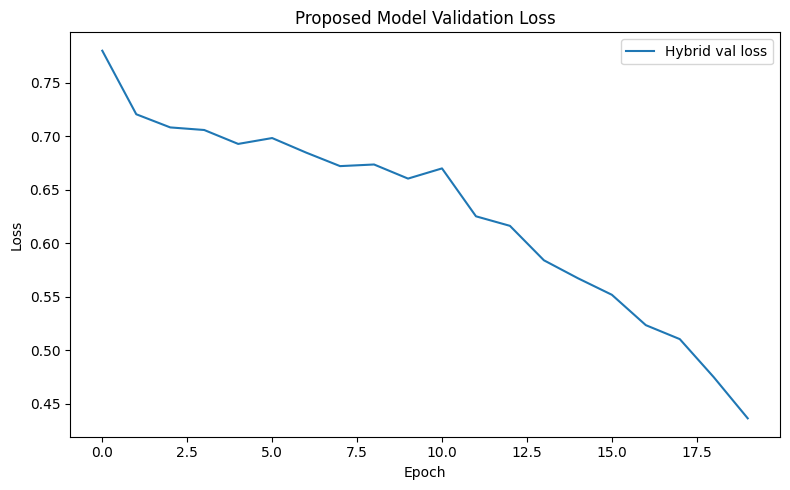

In [21]:
plt.figure(figsize=(8, 5))
plt.plot(hybrid_history['val_loss'], label='Hybrid val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Proposed Model Validation Loss')
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['figures_dir'], 'fig01_loss_curves.png'), dpi=300)
plt.show()


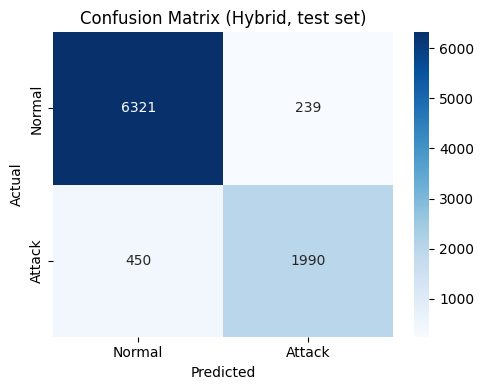

In [22]:
hybrid_probs, hybrid_targets = test_predictions["hybrid"]
hybrid_pred_labels = (hybrid_probs >= 0.5).astype(int)

plt.figure(figsize=(5, 4))
cm = confusion_matrix(hybrid_targets, hybrid_pred_labels, labels=[0, 1])
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Normal", "Attack"],
    yticklabels=["Normal", "Attack"],
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Hybrid, test set)")
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["figures_dir"], "fig02_confusion_or_scatter.png"), dpi=300)
plt.show()


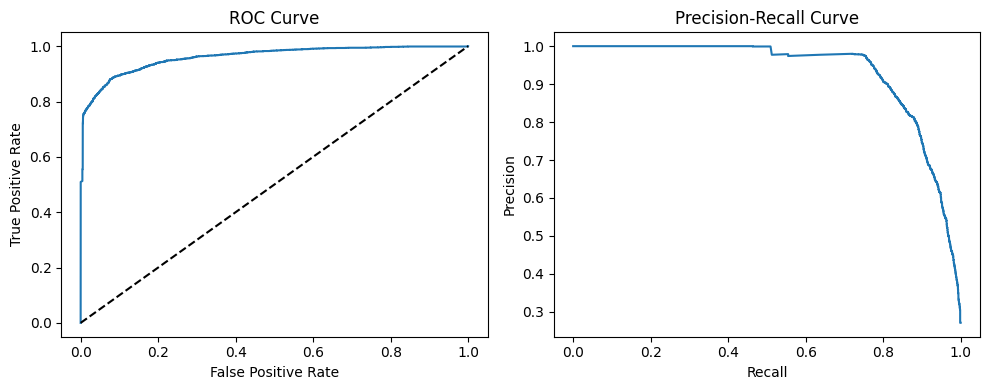

In [23]:
if len(np.unique(hybrid_targets)) == 2:
    fpr, tpr, _ = roc_curve(hybrid_targets, hybrid_probs)
    precision, recall, _ = precision_recall_curve(hybrid_targets, hybrid_probs)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].plot(fpr, tpr)
    axes[0].plot([0, 1], [0, 1], "k--")
    axes[0].set_xlabel("False Positive Rate")
    axes[0].set_ylabel("True Positive Rate")
    axes[0].set_title("ROC Curve")

    axes[1].plot(recall, precision)
    axes[1].set_xlabel("Recall")
    axes[1].set_ylabel("Precision")
    axes[1].set_title("Precision-Recall Curve")

    plt.tight_layout()
    plt.savefig(os.path.join(CONFIG["figures_dir"], "fig03_roc_pr_curve.png"), dpi=300)
    plt.show()
else:
    print("ROC/PR curves skipped: test set contains only one class.")


### Explainable AI — Bayesian Trust Scores

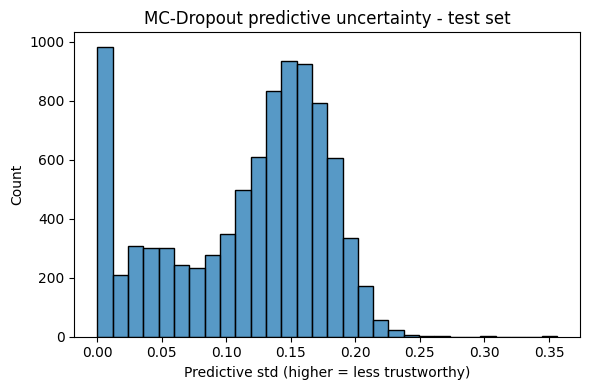

Mean predictive std: 0.11582804471254349
Correlation with absolute prediction error: 0.2891760326678636


In [24]:
# MC-Dropout trust/uncertainty scores
test_X_tensor = torch.tensor(test_X.to_numpy(dtype=np.float32), device=DEVICE)
mean_probs, trust_std = hybrid.predict_with_trust(
    test_X_tensor, n_passes=CONFIG["mc_dropout_passes"]
)

plt.figure(figsize=(6, 4))
sns.histplot(trust_std.ravel(), bins=30)
plt.title("MC-Dropout predictive uncertainty - test set")
plt.xlabel("Predictive std (higher = less trustworthy)")
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["figures_dir"], "fig04_feature_importance.png"), dpi=300)
plt.show()

error_magnitude = np.abs(mean_probs.ravel() - hybrid_targets.astype(float))
trust_flat = trust_std.ravel()
if np.std(trust_flat) > 0 and np.std(error_magnitude) > 0:
    trust_error_corr = float(np.corrcoef(trust_flat, error_magnitude)[0, 1])
else:
    trust_error_corr = None

print("Mean predictive std:", float(trust_std.mean()))
print("Correlation with absolute prediction error:", trust_error_corr)


### Error Analysis

False negatives: 450 / 2440 attacks missed
False positives: 239 / 6560 normal flows flagged


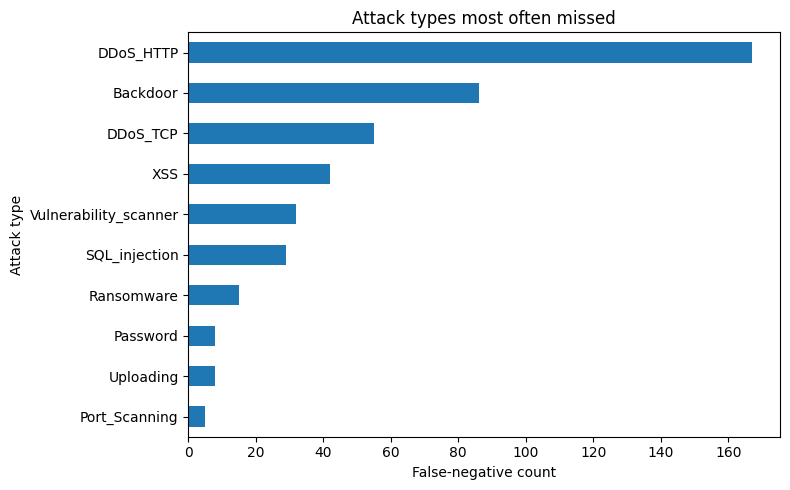

In [25]:
# Error analysis
test_attack_types = (
    df.loc[test_df.index, ATTACK_TYPE_COL]
    if ATTACK_TYPE_COL is not None and ATTACK_TYPE_COL in df.columns
    else None
)

fn_mask = (hybrid_targets == 1) & (hybrid_pred_labels == 0)
fp_mask = (hybrid_targets == 0) & (hybrid_pred_labels == 1)

n_attacks = int((hybrid_targets == 1).sum())
n_normals = int((hybrid_targets == 0).sum())
print(f"False negatives: {int(fn_mask.sum())} / {n_attacks} attacks missed")
print(f"False positives: {int(fp_mask.sum())} / {n_normals} normal flows flagged")

plt.figure(figsize=(8, 5))

if test_attack_types is not None and fn_mask.any():
    missed_types = test_attack_types.to_numpy()[fn_mask].astype(str)
    top_missed = pd.Series(missed_types).value_counts().head(10)

    if not top_missed.empty:
        top_missed.sort_values().plot(kind="barh")
        plt.xlabel("False-negative count")
        plt.ylabel("Attack type")
        plt.title("Attack types most often missed")
    else:
        plt.text(0.5, 0.5, "No attack-type data available for false negatives",
                 ha="center", va="center", transform=plt.gca().transAxes)
        plt.axis("off")
elif not fn_mask.any():
    plt.text(0.5, 0.5, "No false negatives on this test split",
             ha="center", va="center", transform=plt.gca().transAxes)
    plt.axis("off")
else:
    plt.text(0.5, 0.5, "Attack_type column unavailable",
             ha="center", va="center", transform=plt.gca().transAxes)
    plt.axis("off")

plt.tight_layout()
plt.savefig(os.path.join(CONFIG["figures_dir"], "fig05_error_analysis.png"), dpi=300)
plt.show()


### Computational Efficiency

In [26]:
import time
efficiency = {}
for name, model in [('hybrid', hybrid)]:
    total_params = sum((p.numel() for p in model.parameters()))
    trainable_params = sum((p.numel() for p in model.parameters() if p.requires_grad))
    model.eval()
    xb_b, _ = next(iter(test_loader))
    xb_b = xb_b.to(DEVICE)
    with torch.no_grad():
        for _ in range(5):
            _ = model(xb_b)
        if DEVICE.type == 'cuda':
            torch.cuda.synchronize()
        start = time.perf_counter()
        for _ in range(20):
            _ = model(xb_b)
        if DEVICE.type == 'cuda':
            torch.cuda.synchronize()
        elapsed = (time.perf_counter() - start) / 20
    efficiency[name] = {'total_params': total_params, 'trainable_params': trainable_params, 'avg_batch_inference_time_sec': elapsed, 'throughput_samples_per_sec': xb_b.shape[0] / elapsed}
print(json.dumps(efficiency, indent=2))
with open(os.path.join(CONFIG['results_dir'], 'efficiency.json'), 'w') as f:
    json.dump(efficiency, f, indent=2)


{
  "hybrid": {
    "total_params": 4609,
    "trainable_params": 4609,
    "avg_batch_inference_time_sec": 0.015787474449996352,
    "throughput_samples_per_sec": 16215.386495846975
  }
}
